In [1]:
import numpy as np
import pandas as pd
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import matplotlib.pyplot as plt


In [2]:

# Load your dataset (adjust the path to where your file is located)
data = pd.read_csv('../../data/Tdata.csv')

# Function to create dataset matrix for LSTM
def create_dataset(dataset, look_back=1):
    X, Y = [], []
    for i in range(len(dataset) - look_back - 1):
        a = dataset[i:(i + look_back), :]
        X.append(a)
        Y.append(dataset[i + look_back, :])
    return np.array(X), np.array(Y)

# Function to build and train LSTM model with given hyperparameters
def train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer):
    model = Sequential()
    model.add(LSTM(units, return_sequences=True, input_shape=(X_train.shape[1], X_train.shape[2])))
    model.add(Dropout(dropout_rate))
    model.add(LSTM(units // 2, return_sequences=False))
    model.add(Dense(1))

    model.compile(optimizer=optimizer, loss='mean_squared_error')

    early_stop = EarlyStopping(monitor='val_loss', patience=10)
    reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=5, min_lr=0.001)

    history = model.fit(X_train, y_train, epochs=epochs, batch_size=batch_size, validation_split=0.1, verbose=1, callbacks=[early_stop, reduce_lr])

    test_predict = model.predict(X_test)
    return model, test_predict, history


In [3]:
# Preparing data for 'DL_TRAFFIC_MB'
feature = 'DL_TRAFFIC_MB'

# Normalize the 'DL_TRAFFIC_MB' data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_data = scaler.fit_transform(data[[feature]])


In [4]:
# Split the data into training and test sets (80% train, 20% test)
train_size = int(len(scaled_data) * 0.8)
train, test = scaled_data[:train_size], scaled_data[train_size:]

# Create dataset for LSTM (look_back=1)
X_train, y_train = create_dataset(train, look_back=1)
X_test, y_test = create_dataset(test, look_back=1)

# Reshape input data to 3D (samples, timesteps, features) for LSTM input
X_train = np.reshape(X_train, (X_train.shape[0], X_train.shape[1], 1))
X_test = np.reshape(X_test, (X_test.shape[0], X_test.shape[1], 1))


In [5]:
# Manual hyperparameter tuning loop
best_mse = float('inf')
best_params = {}
best_model = None
best_history = None

In [6]:
# Loop through different hyperparameter configurations
for units in [50, 100, 150]:
    for dropout_rate in [0.2, 0.3, 0.4]:
        for batch_size in [32, 64]:
            for epochs in [50, 100, 150]:
                for optimizer in ['adam', 'rmsprop']:
                    print(f'Training with units={units}, dropout_rate={dropout_rate}, batch_size={batch_size}, epochs={epochs}, optimizer={optimizer}')
                    model, test_predict, history = train_lstm_model(X_train, y_train, X_test, y_test, units, dropout_rate, batch_size, epochs, optimizer)
                    
                    # Calculate MSE with normalized data
                    mse = mean_squared_error(y_test, test_predict)
                    print(f'MSE (normalized): {mse}')
                    
                    # Track the best model
                    if mse < best_mse:
                        best_mse = mse
                        best_params = {'units': units, 'dropout_rate': dropout_rate, 'batch_size': batch_size, 'epochs': epochs, 'optimizer': optimizer}
                        best_model = model
                        best_history = history

print(f'Best MSE (normalized): {best_mse} with params: {best_params}')


Training with units=50, dropout_rate=0.2, batch_size=32, epochs=50, optimizer=adam
Epoch 1/50
9/9 [==============================] - 18s 389ms/step - loss: 0.2062 - val_loss: 0.2438 - lr: 0.0010
Epoch 2/50
9/9 [==============================] - 0s 9ms/step - loss: 0.1720 - val_loss: 0.2029 - lr: 0.0010
Epoch 3/50
9/9 [==============================] - 0s 9ms/step - loss: 0.1386 - val_loss: 0.1599 - lr: 0.0010
Epoch 4/50
9/9 [==============================] - 0s 9ms/step - loss: 0.1036 - val_loss: 0.1146 - lr: 0.0010
Epoch 5/50
9/9 [==============================] - 0s 10ms/step - loss: 0.0683 - val_loss: 0.0694 - lr: 0.0010
Epoch 6/50
9/9 [==============================] - 0s 13ms/step - loss: 0.0371 - val_loss: 0.0311 - lr: 0.0010
Epoch 7/50
9/9 [==============================] - 0s 14ms/step - loss: 0.0144 - val_loss: 0.0082 - lr: 0.0010
Epoch 8/50
9/9 [==============================] - 0s 11ms/step - loss: 0.0081 - val_loss: 0.0012 - lr: 0.0010
Epoch 9/50
9/9 [======================

Epoch 17/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0069 - val_loss: 0.0027 - lr: 0.0010
Epoch 18/100
3/3 [==============================] - 3s 5ms/step
MSE (normalized): 0.0453779856370849
Training with units=50, dropout_rate=0.2, batch_size=32, epochs=100, optimizer=rmsprop
Epoch 1/100
9/9 [==============================] - 18s 583ms/step - loss: 0.1920 - val_loss: 0.2186 - lr: 0.0010
Epoch 2/100
9/9 [==============================] - 0s 15ms/step - loss: 0.1494 - val_loss: 0.1734 - lr: 0.0010
Epoch 3/100
9/9 [==============================] - 0s 16ms/step - loss: 0.1149 - val_loss: 0.1306 - lr: 0.0010
Epoch 4/100
9/9 [==============================] - 0s 16ms/step - loss: 0.0823 - val_loss: 0.0915 - lr: 0.0010
Epoch 5/100
9/9 [==============================] - 0s 17ms/step - loss: 0.0532 - val_loss: 0.0570 - lr: 0.0010
Epoch 6/100
9/9 [==============================] - 0s 15ms/step - loss: 0.0318 - val_loss: 0.0295 - lr: 0.0010
Epoch 7/100
9/9 [===============

3/3 [==============================] - 3s 6ms/step
MSE (normalized): 0.043002871353145275
Training with units=50, dropout_rate=0.2, batch_size=32, epochs=150, optimizer=rmsprop
Epoch 1/150
9/9 [==============================] - 20s 557ms/step - loss: 0.1901 - val_loss: 0.2147 - lr: 0.0010
Epoch 2/150
9/9 [==============================] - 0s 15ms/step - loss: 0.1470 - val_loss: 0.1690 - lr: 0.0010
Epoch 3/150
9/9 [==============================] - 0s 34ms/step - loss: 0.1114 - val_loss: 0.1282 - lr: 0.0010
Epoch 4/150
9/9 [==============================] - 0s 22ms/step - loss: 0.0800 - val_loss: 0.0883 - lr: 0.0010
Epoch 5/150
9/9 [==============================] - 0s 17ms/step - loss: 0.0509 - val_loss: 0.0536 - lr: 0.0010
Epoch 6/150
9/9 [==============================] - 0s 11ms/step - loss: 0.0293 - val_loss: 0.0274 - lr: 0.0010
Epoch 7/150
9/9 [==============================] - 0s 13ms/step - loss: 0.0153 - val_loss: 0.0118 - lr: 0.0010
Epoch 8/150
9/9 [===========================

Epoch 10/50
5/5 [==============================] - 0s 18ms/step - loss: 0.0295 - val_loss: 0.0284 - lr: 0.0010
Epoch 11/50
5/5 [==============================] - 0s 24ms/step - loss: 0.0166 - val_loss: 0.0139 - lr: 0.0010
Epoch 12/50
5/5 [==============================] - 0s 19ms/step - loss: 0.0096 - val_loss: 0.0055 - lr: 0.0010
Epoch 13/50
5/5 [==============================] - 0s 18ms/step - loss: 0.0072 - val_loss: 0.0020 - lr: 0.0010
Epoch 14/50
5/5 [==============================] - 0s 17ms/step - loss: 0.0074 - val_loss: 9.3530e-04 - lr: 0.0010
Epoch 15/50
5/5 [==============================] - 0s 22ms/step - loss: 0.0077 - val_loss: 8.0425e-04 - lr: 0.0010
Epoch 16/50
5/5 [==============================] - 0s 27ms/step - loss: 0.0078 - val_loss: 0.0010 - lr: 0.0010
Epoch 17/50
5/5 [==============================] - 0s 19ms/step - loss: 0.0070 - val_loss: 0.0015 - lr: 0.0010
Epoch 18/50
5/5 [==============================] - 0s 32ms/step - loss: 0.0070 - val_loss: 0.0023 - lr: 

5/5 [==============================] - 0s 20ms/step - loss: 0.0079 - val_loss: 0.0010 - lr: 0.0010
Epoch 17/100
5/5 [==============================] - 0s 19ms/step - loss: 0.0073 - val_loss: 0.0013 - lr: 0.0010
Epoch 18/100
5/5 [==============================] - 0s 20ms/step - loss: 0.0076 - val_loss: 0.0018 - lr: 0.0010
Epoch 19/100
5/5 [==============================] - 0s 18ms/step - loss: 0.0066 - val_loss: 0.0025 - lr: 0.0010
Epoch 20/100
5/5 [==============================] - 0s 16ms/step - loss: 0.0070 - val_loss: 0.0027 - lr: 0.0010
Epoch 21/100
5/5 [==============================] - 0s 17ms/step - loss: 0.0071 - val_loss: 0.0027 - lr: 0.0010
Epoch 22/100
5/5 [==============================] - 0s 18ms/step - loss: 0.0065 - val_loss: 0.0027 - lr: 0.0010
Epoch 23/100
5/5 [==============================] - 0s 22ms/step - loss: 0.0064 - val_loss: 0.0026 - lr: 0.0010
Epoch 24/100
5/5 [==============================] - 0s 21ms/step - loss: 0.0072 - val_loss: 0.0028 - lr: 0.0010
Epoch

...

5/5 [==============================] - 0s 32ms/step - loss: 0.0078 - val_loss: 0.0013 - lr: 0.0010
Epoch 12/150
5/5 [==============================] - 0s 48ms/step - loss: 0.0077 - val_loss: 0.0039 - lr: 0.0010
Epoch 13/150
5/5 [==============================] - 0s 41ms/step - loss: 0.0077 - val_loss: 0.0021 - lr: 0.0010
Epoch 14/150
5/5 [==============================] - 0s 48ms/step - loss: 0.0075 - val_loss: 0.0018 - lr: 0.0010
Epoch 15/150
5/5 [==============================] - 0s 70ms/step - loss: 0.0078 - val_loss: 0.0052 - lr: 0.0010
Epoch 16/150
5/5 [==============================] - 0s 49ms/step - loss: 0.0070 - val_loss: 0.0051 - lr: 0.0010
Epoch 17/150
5/5 [==============================] - 0s 27ms/step - loss: 0.0073 - val_loss: 0.0041 - lr: 0.0010
Epoch 18/150
5/5 [==============================] - 0s 37ms/step - loss: 0.0069 - val_loss: 0.0012 - lr: 0.0010
Epoch 19/150
5/5 [==============================] - 0s 36ms/step - loss: 0.0072 - val_loss: 0.0044 - lr: 0.0010
Epoch

9/9 [==============================] - 0s 23ms/step - loss: 0.0044 - val_loss: 0.0026 - lr: 0.0010
Epoch 25/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0039 - val_loss: 8.8900e-04 - lr: 0.0010
Epoch 26/50
9/9 [==============================] - 0s 21ms/step - loss: 0.0039 - val_loss: 0.0022 - lr: 0.0010
Epoch 27/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0036 - val_loss: 0.0011 - lr: 0.0010
Epoch 28/50
9/9 [==============================] - 0s 22ms/step - loss: 0.0039 - val_loss: 0.0013 - lr: 0.0010
Epoch 29/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0034 - val_loss: 9.6536e-04 - lr: 0.0010
Epoch 30/50
9/9 [==============================] - 0s 20ms/step - loss: 0.0033 - val_loss: 0.0010 - lr: 0.0010
Epoch 31/50
3/3 [==============================] - 3s 6ms/step
MSE (normalized): 0.013397074678354742
Training with units=150, dropout_rate=0.4, batch_size=32, epochs=100, optimizer=adam
Epoch 1/100
9/9 [=======================

Epoch 2/150
9/9 [==============================] - 0s 24ms/step - loss: 0.1060 - val_loss: 0.0960 - lr: 0.0010
Epoch 3/150
9/9 [==============================] - 0s 25ms/step - loss: 0.0484 - val_loss: 0.0359 - lr: 0.0010
Epoch 4/150
9/9 [==============================] - 0s 28ms/step - loss: 0.0166 - val_loss: 0.0107 - lr: 0.0010
Epoch 5/150
9/9 [==============================] - 0s 27ms/step - loss: 0.0095 - val_loss: 0.0041 - lr: 0.0010
Epoch 6/150
9/9 [==============================] - 0s 26ms/step - loss: 0.0083 - val_loss: 0.0038 - lr: 0.0010
Epoch 7/150
9/9 [==============================] - 0s 22ms/step - loss: 0.0077 - val_loss: 0.0030 - lr: 0.0010
Epoch 8/150
9/9 [==============================] - 0s 23ms/step - loss: 0.0075 - val_loss: 0.0071 - lr: 0.0010
Epoch 9/150
9/9 [==============================] - 0s 19ms/step - loss: 0.0075 - val_loss: 0.0022 - lr: 0.0010
Epoch 10/150
9/9 [==============================] - 0s 22ms/step - loss: 0.0073 - val_loss: 9.7985e-04 - lr: 0.0

Epoch 7/100
5/5 [==============================] - 0s 33ms/step - loss: 0.0180 - val_loss: 0.0080 - lr: 0.0010
Epoch 8/100
5/5 [==============================] - 0s 33ms/step - loss: 0.0067 - val_loss: 7.2073e-04 - lr: 0.0010
Epoch 9/100
5/5 [==============================] - 0s 35ms/step - loss: 0.0101 - val_loss: 0.0023 - lr: 0.0010
Epoch 10/100
5/5 [==============================] - 0s 34ms/step - loss: 0.0118 - val_loss: 0.0011 - lr: 0.0010
Epoch 11/100
5/5 [==============================] - 0s 34ms/step - loss: 0.0086 - val_loss: 0.0011 - lr: 0.0010
Epoch 12/100
5/5 [==============================] - 0s 32ms/step - loss: 0.0067 - val_loss: 0.0037 - lr: 0.0010
Epoch 13/100
5/5 [==============================] - 0s 32ms/step - loss: 0.0063 - val_loss: 0.0054 - lr: 0.0010
Epoch 14/100
5/5 [==============================] - 0s 35ms/step - loss: 0.0066 - val_loss: 0.0050 - lr: 0.0010
Epoch 15/100
5/5 [==============================] - 0s 40ms/step - loss: 0.0065 - val_loss: 0.0031 - lr

Epoch 13/150
5/5 [==============================] - 0s 51ms/step - loss: 0.0071 - val_loss: 0.0047 - lr: 0.0010
Epoch 14/150
5/5 [==============================] - 0s 45ms/step - loss: 0.0064 - val_loss: 0.0038 - lr: 0.0010
Epoch 15/150
5/5 [==============================] - 0s 30ms/step - loss: 0.0061 - val_loss: 0.0027 - lr: 0.0010
Epoch 16/150
5/5 [==============================] - 0s 32ms/step - loss: 0.0059 - val_loss: 0.0020 - lr: 0.0010
Epoch 17/150
5/5 [==============================] - 0s 32ms/step - loss: 0.0058 - val_loss: 0.0021 - lr: 0.0010
Epoch 18/150
5/5 [==============================] - 0s 30ms/step - loss: 0.0061 - val_loss: 0.0022 - lr: 0.0010
Epoch 19/150
5/5 [==============================] - 0s 33ms/step - loss: 0.0056 - val_loss: 0.0022 - lr: 0.0010
Epoch 20/150
3/3 [==============================] - 5s 6ms/step
MSE (normalized): 0.03818857574831282
Training with units=150, dropout_rate=0.4, batch_size=64, epochs=150, optimizer=rmsprop
Epoch 1/150
5/5 [=========

3/3 [==============================] - 0s 4ms/step


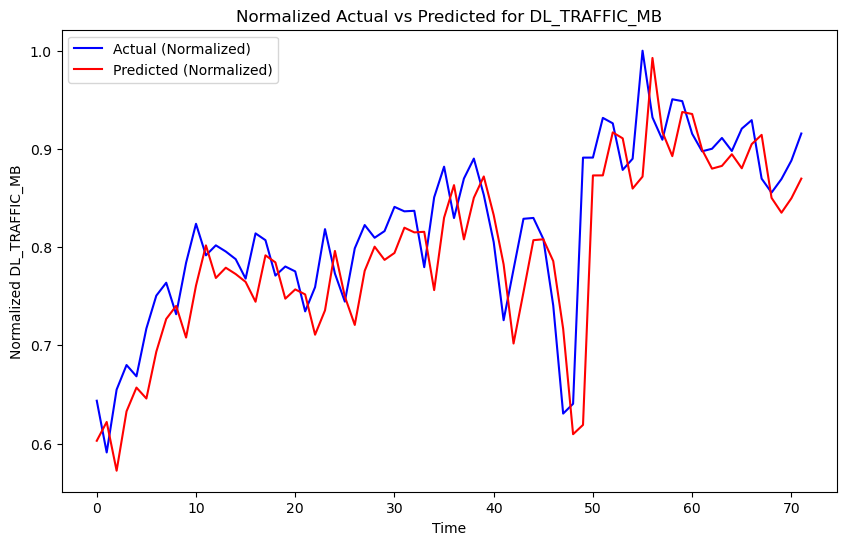

In [7]:
# Plot the best model's predictions with normalized values
best_test_predict = best_model.predict(X_test)

plt.figure(figsize=(10, 6))
plt.plot(y_test, label='Actual (Normalized)', color='blue')
plt.plot(best_test_predict, label='Predicted (Normalized)', color='red')
plt.title(f'Normalized Actual vs Predicted for {feature}')
plt.xlabel('Time')
plt.ylabel(f'Normalized {feature}')
plt.legend()
plt.show()

In [8]:
data

,Date,Avg_Usr,Avg_Usr_TP_DL,Avg_Usr_TP_UL,CSSR,DL_256QAM_PROPORTION,DL_LATENCY,DL_PACK_LOSS_RATE,DL_QPSK_PROPORTION,DL_TRAFFIC_MB,Max_Usr,S1_SIG_SUCC,TOTAL_DOWNTIME,Traffic,UL_QPSK_PROPORTION,UL_TRAFFIC_MB
0,1-Sep-22,16209.61,3.446027,0.564643,98.698393,0.745357,11.741116,0.101875,36.163527,28748026.10,32848,251968.1429,393.651786,32890183.17,37.050402,4142157.11
1,2-Sep-22,16003.68,3.250536,0.582187,98.690223,0.700536,11.614241,0.115580,35.475402,29619777.66,32313,243918.5625,389.156250,34033315.47,38.724911,4413537.60
2,3-Sep-22,16058.39,3.597009,0.609911,98.715045,0.739732,11.503259,0.096250,35.623393,29102851.45,32565,246798.6027,388.062500,33383868.74,36.708884,4281017.27
3,4-Sep-22,16390.15,3.726696,0.561250,98.599777,0.746696,11.807366,0.110536,35.997411,28466880.25,33303,257327.6563,387.245536,32606986.82,36.628527,4140106.66
4,5-Sep-22,16051.58,3.726473,0.537813,98.653527,0.751071,11.534911,0.111250,35.609866,28558733.04,32314,256012.4866,390.343750,32652591.96,37.344955,4093859.29
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
361,28-Aug-23,23298.68,7.064972,0.477116,99.415142,0.773226,7.505920,0.078786,38.537059,56768939.70,58629,127670.3321,1092.662239,63974723.71,42.272201,7205784.11
362,29-Aug-23,24511.92,6.966452,0.490361,99.463776,0.727324,7.704269,0.097002,38.737799,57456743.34,54688,129612.0247,1074.193548,64944563.74,40.884345,7487820.29
363,30-Aug-23,24467.48,6.898596,0.493188,99.626964,0.754516,7.891157,0.096129,38.392467,58389814.53,56111,133872.1556,362.741936,65854384.38,40.078159,7464569.80
364,31-Aug-23,23803.97,7.090190,0.510664,99.661120,0.809222,7.563378,0.088520,38.284099,59759544.72,51682,134106.0171,0.000000,67421649.20,39.138444,7662104.58
